## esempio pag 319 slide python

In [1]:
# Importazione delle librerie necessarie
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Caricamento del dataset
data = load_iris()
X = data.data # le caratteristiche
y = data.target # le etichette

# Divisione dei dati in set di addestramento e di test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creazione del modello di classificazione
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Addestramento del modello
model.fit(X_train, y_train)

# Predizione delle etichette per il set di test
predictions = model.predict(X_test)

# Calcolo dell'accuratezza del modello
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


Mean Square Error ~ 0.555891598695242


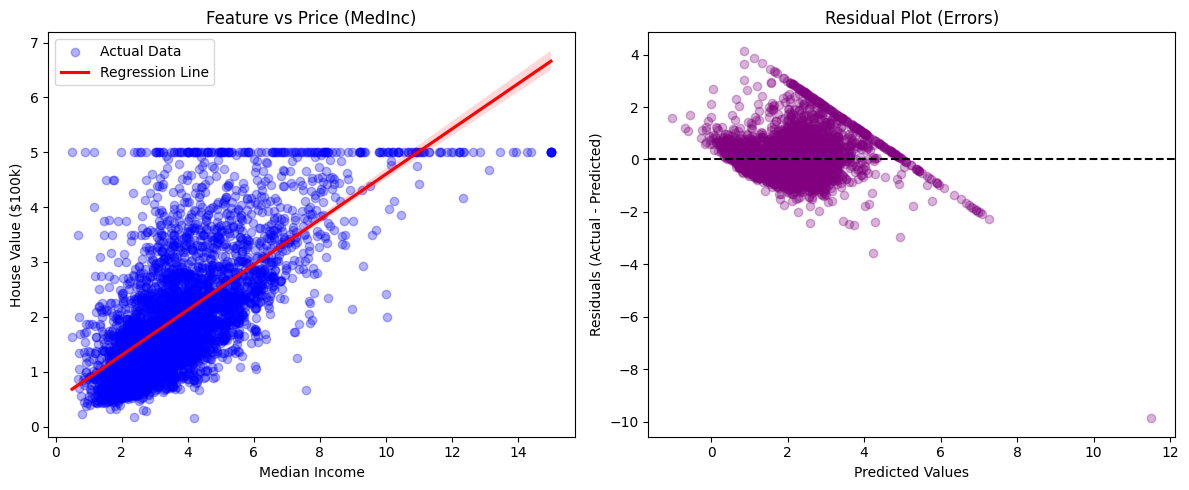

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Load Data
housing = fetch_california_housing()


## Applicare rimozione outlier con z score = 3


X = housing.data
y = housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print("Mean Square Error ~",mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($100k)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

## analisi grafici

quello a sx è il grafico della regressione, quanto si discostano i risultati ottenuti da quelli attesi

a dx invece è solo la misura dell'errore. nota bene che se lo zero fosse stato piu sotto, si era verificato un overfitting, ma cosi è piu bilanciato

lo 0,55 è circa l'errore ottenuto

### ora proviamo a rimuovere gli outliers e vediamo se l'errore (mean square error calcolato in precedenza circa 0.55) è diminuito

si applica il metodo di z score = 3

In [5]:
# CELLA 1 - TRAINING (con rimozione outlier z-score=3)

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1) Load Data
housing = fetch_california_housing()

# 2) Converti in pandas
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Target"] = housing.target

# 3) Rimozione outlier con Z-score = 3 (sulle feature)
feature_cols = housing.feature_names

media = df[feature_cols].mean()
dev_std = df[feature_cols].std()

z = (df[feature_cols] - media) / dev_std
mask = (z.abs() < 3).all(axis=1)

df_clean = df[mask].copy()

print("Campioni originali:", len(df))
print("Campioni dopo rimozione outlier:", len(df_clean))

# 4) X, y puliti
X = df_clean[feature_cols]
y = df_clean["Target"]

# 5) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) Train
model = LinearRegression()
model.fit(X_train, y_train)

# 7) Predict + MSE
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print("Mean Square Error ~", mse)

Campioni originali: 20640
Campioni dopo rimozione outlier: 19794
Mean Square Error ~ 0.4731016254420819


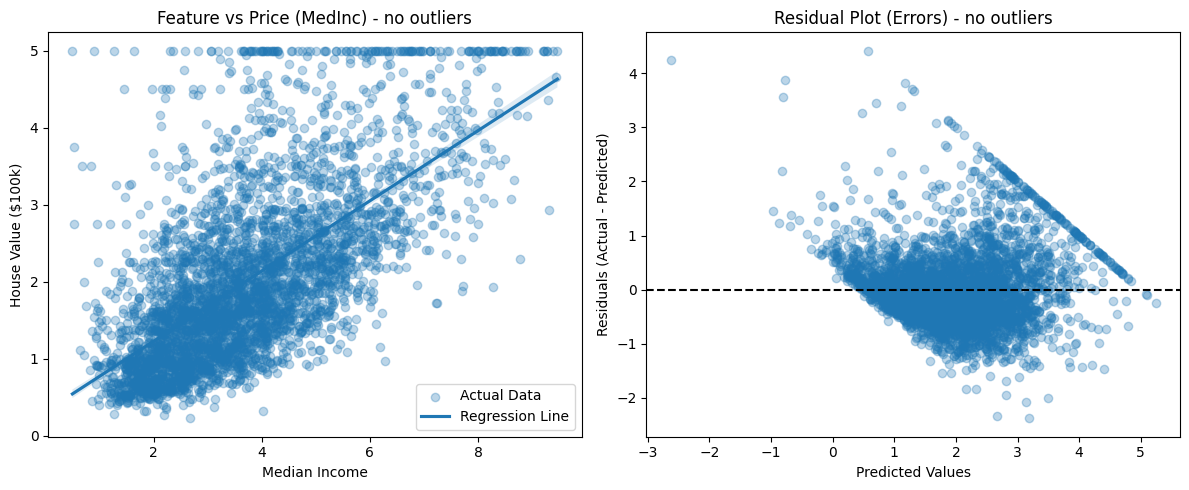

In [6]:
# CELLA 2 - VISUALIZZAZIONE ERRORE (usa variabili create nella cella 1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# --- Plot 1: Feature vs Target con retta (MedInc) ---
plt.subplot(1, 2, 1)

plt.scatter(X_test["MedInc"], y_test, alpha=0.3, label="Actual Data")
sns.regplot(x=X_test["MedInc"], y=y_test, scatter=False, label="Regression Line")

plt.title("Feature vs Price (MedInc) - no outliers")
plt.xlabel("Median Income")
plt.ylabel("House Value ($100k)")
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color="black", linestyle="--")

plt.title("Residual Plot (Errors) - no outliers")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()
plt.show()

## analisi

abbiamo ottenuto un errore di ~ 0.473 che va bene, abbiamo diminuito

notiamo anche che dai grafici di prima c'era un unico puntino in basso a dx che era completamente fuori dal grafico ed ora è stato rimosso

# classificazione

## ora applichiamo la linear regression per un compito di classificazione binaria

la linea bisettrice non è più una predizione ma un divisore e i campioni vengono classificati da una parte o dall'altra dello spazio
viene applicata una simoide che schiaccia il risultato tra 0 e 1. tra 0 e 0.5 sei una cosa, tra 0.5 e 1 sei l'altro

In [8]:
# Importazione delle librerie necessarie

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score


# Caricamento del dataset

data = load_iris()

X = data.data  # le caratteristiche

y = data.target  # le etichette


# Divisione dei dati in set di addestramento e di test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)


# Creazione del modello di classificazione

model = LogisticRegression()


# Addestramento del modello

model.fit(X_train, y_train)


# Predizione delle etichette per il set di test

predictions = model.predict(X_test)


# Calcolo dell'accuratezza del modello

accuracy = accuracy_score(y_test, predictions)

print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.93


è stato cambiato il random state. se metti 42 viene un accurancy di 1.00 perche negli algoritmi 42 è il seme "delle risposte facili" quindi è molto probabile che ci azzecchi tutte le volte

se invece cambio random state, ottengo una accurancy minore, più veririera 


### gradico heatmap - Matrice di confusione - aiuta a capire dove il modello si confonde e quindi dove migliorare